# **Decision Tree Regression — Hands-on Demo**

This notebook is a **hands-on companion** to the Decision Tree Regressor notes.

**What you'll see in this notebook:**
1. The exact **salary-prediction worked example** from the notes — computed with real code
2. A cross-check against `sklearn`'s actual `DecisionTreeRegressor` to confirm the same split is chosen
3. The classic **"staircase" visualization** that makes Decision Tree Regression intuitive
4. A **leaf-averaging** demonstration (why predictions look like flat steps, not a smooth line)
5. **Overfitting vs pruning** for regression trees (MSE-based, the regression equivalent of Notebook 07's demo)
6. A direct comparison against **Linear Regression** to show how trees capture non-linear patterns

> **Real-life analogy reminder:** A regression tree leaf predicts the **average** of the training
> values that land there — exactly like KNN Regression's "average of neighbors," except the
> "neighborhood" is defined by learned splits instead of raw distance.


## 1. The Worked Example — Predicting Salary from Career Gap

The notes use 5 training records: salaries **[40k, 42k, 52k, 60k, 56k]**, with an associated
"career gap" feature. Let's set up the same 5 points and verify the variance calculations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

salaries = np.array([40, 42, 52, 60, 56])
gap      = np.array([1, 2.3, 3, 4, 5])   # career gap in years (chosen to reproduce the notes' groupings)

def variance(arr):
    return np.var(arr)  # population variance (matches the notes' formula, dividing by n)

root_var = variance(salaries)
print(f"Mean salary: {salaries.mean()}k")
print(f"Root variance: {root_var}  (notes say 60.8)")


Mean salary: 50.0k
Root variance: 60.8  (notes say 60.8)


## 2. Comparing the Two Candidate Splits


In [2]:
def variance_reduction(left, right, root_var):
    n = len(left) + len(right)
    weighted = (len(left)/n)*variance(left) + (len(right)/n)*variance(right)
    return root_var - weighted

# Split A: gap <= 2
leftA, rightA = salaries[gap <= 2], salaries[gap > 2]
vr_a = variance_reduction(leftA, rightA, root_var)
print(f"Split A (gap <= 2):   left={leftA}, right={rightA}  ->  Variance Reduction = {vr_a:.3f}")

# Split B: gap <= 2.5
leftB, rightB = salaries[gap <= 2.5], salaries[gap > 2.5]
vr_b = variance_reduction(leftB, rightB, root_var)
print(f"Split B (gap <= 2.5): left={leftB}, right={rightB}  ->  Variance Reduction = {vr_b:.3f}")

winner = "Split B" if vr_b > vr_a else "Split A"
print(f"\n>>> {winner} wins (higher variance reduction) <<<")
print("This matches the notes' conclusion: Split B (threshold <= 2.5) is the better split.")


Split A (gap <= 2):   left=[40], right=[42 52 60 56]  ->  Variance Reduction = 25.000
Split B (gap <= 2.5): left=[40 42], right=[52 60 56]  ->  Variance Reduction = 54.000

>>> Split B wins (higher variance reduction) <<<
This matches the notes' conclusion: Split B (threshold <= 2.5) is the better split.


## 3. Cross-Checking with `sklearn`'s Real `DecisionTreeRegressor`

Instead of manually trying two candidate thresholds, let's let `sklearn` brute-force search **every**
possible threshold and see which one it actually picks.

In [3]:
from sklearn.tree import DecisionTreeRegressor, export_text

X = gap.reshape(-1, 1)
y = salaries

tree = DecisionTreeRegressor(max_depth=1, criterion='squared_error')
tree.fit(X, y)

print(export_text(tree, feature_names=['gap']))
print("\nPredictions:")
print(f"  gap=1.5 (<= threshold) -> predicted salary: {tree.predict([[1.5]])[0]}k")
print(f"  gap=4.0 (> threshold)  -> predicted salary: {tree.predict([[4.0]])[0]}k")
print("\nThese leaf predictions (41k and 56k) match the notes EXACTLY:")
print(f"  Leaf 1 average: {leftB.mean()}k  |  Leaf 2 average: {rightB.mean()}k")


|--- gap <= 2.65
|   |--- value: [41.00]
|--- gap >  2.65
|   |--- value: [56.00]


Predictions:
  gap=1.5 (<= threshold) -> predicted salary: 41.0k
  gap=4.0 (> threshold)  -> predicted salary: 56.0k

These leaf predictions (41k and 56k) match the notes EXACTLY:
  Leaf 1 average: 41.0k  |  Leaf 2 average: 56.0k


## 4. The Classic "Staircase" Visualization

This is the single most useful visual for understanding regression trees: predictions are **flat steps**,
not a smooth line — because every point in a leaf gets the exact same (average) prediction.

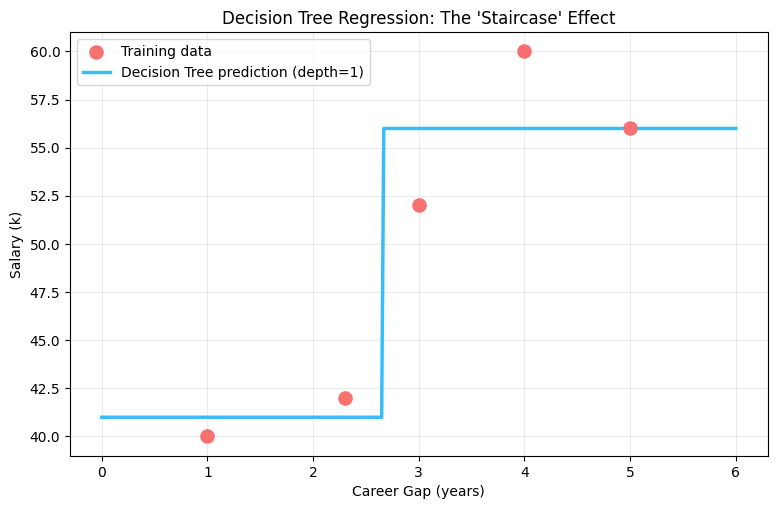

In [4]:
gap_range = np.linspace(0, 6, 300).reshape(-1, 1)
predictions = tree.predict(gap_range)

plt.figure(figsize=(9, 5.5))
plt.scatter(gap, salaries, color="#f87171", s=90, zorder=5, label="Training data")
plt.plot(gap_range, predictions, color="#38bdf8", linewidth=2.5, label="Decision Tree prediction (depth=1)")
plt.xlabel("Career Gap (years)")
plt.ylabel("Salary (k)")
plt.title("Decision Tree Regression: The 'Staircase' Effect")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 5. Adding More Depth — More Steps, Finer Predictions

Let's allow the tree to grow deeper and watch the staircase get more detailed (more, smaller steps).

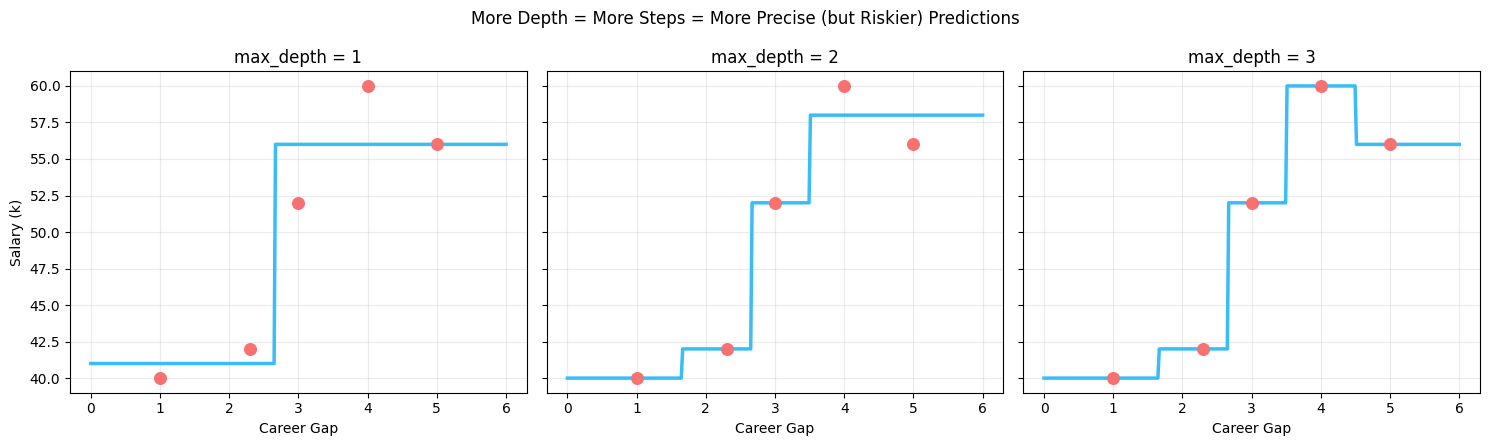

With only 5 training points, depth=3 essentially memorizes every point -- a preview of overfitting,
explored properly with a larger dataset in Section 6 below.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, depth in zip(axes, [1, 2, 3]):
    t = DecisionTreeRegressor(max_depth=depth, criterion='squared_error')
    t.fit(X, y)
    preds = t.predict(gap_range)
    ax.scatter(gap, salaries, color="#f87171", s=70, zorder=5)
    ax.plot(gap_range, preds, color="#38bdf8", linewidth=2.5)
    ax.set_title(f"max_depth = {depth}")
    ax.set_xlabel("Career Gap")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Salary (k)")
plt.suptitle("More Depth = More Steps = More Precise (but Riskier) Predictions")
plt.tight_layout()
plt.show()

print("With only 5 training points, depth=3 essentially memorizes every point -- a preview of overfitting,")
print("explored properly with a larger dataset in Section 6 below.")


## 6. Overfitting vs Pruning — Now with a Larger, Realistic Dataset

Just like the classification notebook, 5 points is too small to show a convincing overfitting curve.
Let's generate a bigger synthetic regression dataset with real noise.

In [6]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X_big, y_big = make_regression(n_samples=500, n_features=1, noise=25, random_state=42)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_big, y_big, test_size=0.25, random_state=42)

full_tree = DecisionTreeRegressor(random_state=42)
full_tree.fit(Xb_train, yb_train)

print("Fully-Grown Regression Tree (no pruning):")
print(f"  Train R2: {r2_score(yb_train, full_tree.predict(Xb_train)):.3f}")
print(f"  Test R2:  {r2_score(yb_test, full_tree.predict(Xb_test)):.3f}")
print(f"  Tree depth: {full_tree.get_depth()}, Leaves: {full_tree.get_n_leaves()}")
print("\nA huge train/test R2 gap -- classic overfitting, exactly like the classification case.")


Fully-Grown Regression Tree (no pruning):
  Train R2: 1.000
  Test R2:  0.662
  Tree depth: 27, Leaves: 375

A huge train/test R2 gap -- classic overfitting, exactly like the classification case.


### 6.1 Pre-Pruning with `max_depth`

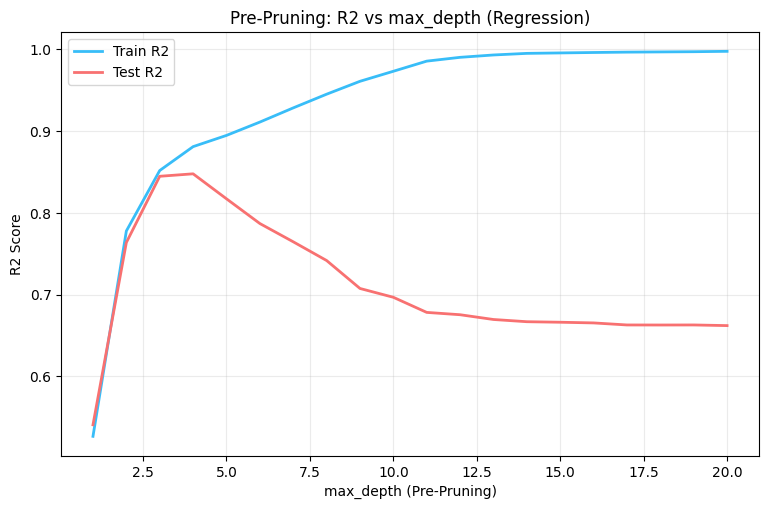

Best max_depth for TEST R2: 4 (test R2 = 0.848)


In [7]:
depths = range(1, 21)
train_r2s, test_r2s = [], []
for d in depths:
    t = DecisionTreeRegressor(max_depth=d, random_state=42)
    t.fit(Xb_train, yb_train)
    train_r2s.append(r2_score(yb_train, t.predict(Xb_train)))
    test_r2s.append(r2_score(yb_test, t.predict(Xb_test)))

plt.figure(figsize=(9, 5.5))
plt.plot(depths, train_r2s, label="Train R2", color="#38bdf8", linewidth=2)
plt.plot(depths, test_r2s, label="Test R2", color="#f87171", linewidth=2)
plt.xlabel("max_depth (Pre-Pruning)")
plt.ylabel("R2 Score")
plt.title("Pre-Pruning: R2 vs max_depth (Regression)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

best_depth = depths[int(np.argmax(test_r2s))]
print(f"Best max_depth for TEST R2: {best_depth} (test R2 = {max(test_r2s):.3f})")


## 7. Decision Tree vs Linear Regression — Capturing Non-Linearity

The notes make the point that trees can capture **non-linear relationships** without manual feature
engineering. Let's demonstrate this on a clearly non-linear (sine wave) dataset.

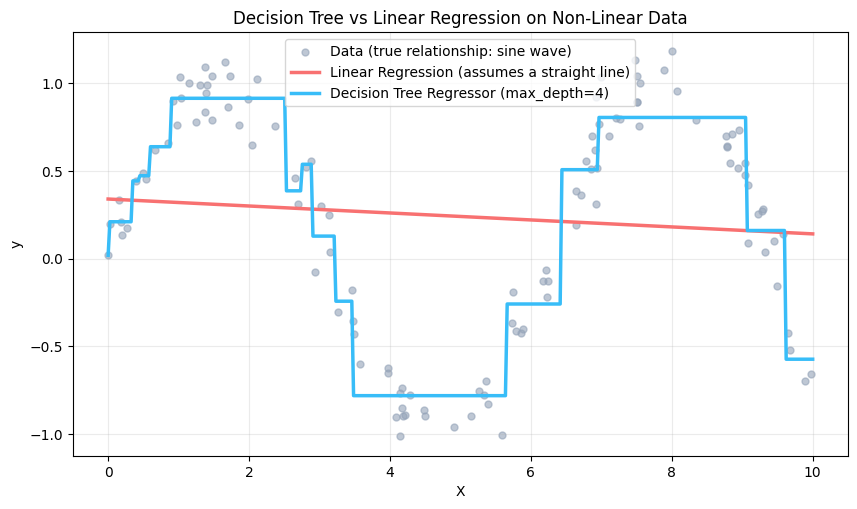

Linear Regression R2: 0.009
Decision Tree R2:     0.943

Linear Regression cannot bend to follow the curve -- the tree's staircase gets much closer.


In [8]:
from sklearn.linear_model import LinearRegression

np.random.seed(1)
X_nl = np.sort(np.random.uniform(0, 10, 120)).reshape(-1, 1)
y_nl = np.sin(X_nl).ravel() + np.random.normal(0, 0.15, 120)

lin_model = LinearRegression().fit(X_nl, y_nl)
tree_model = DecisionTreeRegressor(max_depth=4, random_state=42).fit(X_nl, y_nl)

X_plot = np.linspace(0, 10, 400).reshape(-1, 1)

plt.figure(figsize=(10, 5.5))
plt.scatter(X_nl, y_nl, color="#94a3b8", s=25, alpha=0.6, label="Data (true relationship: sine wave)")
plt.plot(X_plot, lin_model.predict(X_plot), color="#f87171", linewidth=2.5, label="Linear Regression (assumes a straight line)")
plt.plot(X_plot, tree_model.predict(X_plot), color="#38bdf8", linewidth=2.5, label="Decision Tree Regressor (max_depth=4)")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Decision Tree vs Linear Regression on Non-Linear Data")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print(f"Linear Regression R2: {r2_score(y_nl, lin_model.predict(X_nl)):.3f}")
print(f"Decision Tree R2:     {r2_score(y_nl, tree_model.predict(X_nl)):.3f}")
print("\nLinear Regression cannot bend to follow the curve -- the tree's staircase gets much closer.")



-  The notes' salary-prediction example is reproduced with real code — `sklearn`'s tree independently
  confirms the **same split point and the same leaf predictions (41k / 56k)** described in the notes.
-  Regression tree predictions form a **staircase** — flat within each leaf, jumping at each split —
  because every point in a leaf receives the leaf's **average** value.
-  More depth = more (smaller) steps = closer fit, but also **more overfitting risk**, exactly like
  the classification case.
-  **Pre-pruning** (`max_depth`, etc.) works the same way for regression trees, controlling this
  train/test gap.
-  Trees naturally capture **non-linear relationships** that a straight-line model (Linear Regression)
  simply cannot — no manual polynomial feature engineering required.
